MSE: 0.00396
MAE: 0.05299
Naive MSE: 0.00716


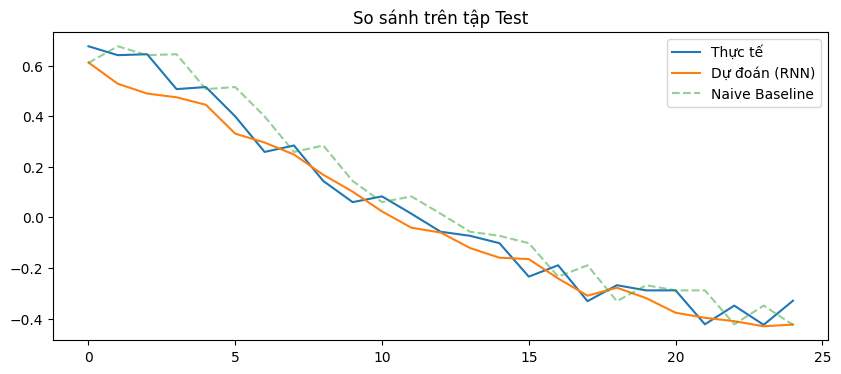

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Dữ liệu (từ đề bài)
time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})

# --- PHẦN A: Tiền xử lý ---
seq_length = 20

# Chia 70% train / 15% val / 15% test không shuffle
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

features = ['feature_1', 'feature_2', 'feature_3']

# Fit trên tập train và transform cho các tập còn lại để tránh data leakage
X_train_scaled = scaler_X.fit_transform(train_df[features])
y_train_scaled = scaler_y.fit_transform(train_df[['target']])

X_val_scaled = scaler_X.transform(val_df[features])
y_val_scaled = scaler_y.transform(val_df[['target']])

X_test_scaled = scaler_X.transform(test_df[features])
y_test_scaled = scaler_y.transform(test_df[['target']])

# Hàm tạo sequences
def create_multivariate_sequences(X, y, seq_length):
    seq_X, seq_y = [], []
    for i in range(len(X) - seq_length):
        seq_X.append(X[i : i + seq_length])
        seq_y.append(y[i + seq_length])
    return torch.FloatTensor(np.array(seq_X)), torch.FloatTensor(np.array(seq_y))

X_train, y_train = create_multivariate_sequences(X_train_scaled, y_train_scaled, seq_length)
X_val, y_val = create_multivariate_sequences(X_val_scaled, y_val_scaled, seq_length)
X_test, y_test = create_multivariate_sequences(X_test_scaled, y_test_scaled, seq_length)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=False)

# --- PHẦN B: Mô hình ---
class MultiVariateRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :]) # Lấy trạng thái ẩn cuối cùng
        return out

model = MultiVariateRNN(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 150
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        preds = model(X_b)
        loss = criterion(preds, y_b)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * X_b.size(0)

    train_losses.append(epoch_train_loss / len(X_train))

    # Tính val loss
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()
        val_losses.append(val_loss)

# --- PHẦN C: Đánh giá ---
model.eval()
with torch.no_grad():
    test_preds = model(X_test)
    # Inverse transform về giá trị thực
    test_preds_inv = scaler_y.inverse_transform(test_preds.numpy())
    y_test_inv = scaler_y.inverse_transform(y_test.numpy())

print(f"MSE: {mean_squared_error(y_test_inv, test_preds_inv):.5f}")
print(f"MAE: {mean_absolute_error(y_test_inv, test_preds_inv):.5f}")

# Baseline Naive (giá trị tiếp theo = giá trị target ở bước t-1)
# Do tập test bắt đầu từ index 20 (sau seq_length), baseline là target của bước ngay trước đó.
naive_preds = df['target'].values[train_size+val_size+seq_length-1 : -1]
print(f"Naive MSE: {mean_squared_error(y_test_inv, naive_preds):.5f}")

plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label="Thực tế")
plt.plot(test_preds_inv, label="Dự đoán (RNN)")
plt.plot(naive_preds, label="Naive Baseline", alpha=0.5, linestyle='--')
plt.legend()
plt.title("So sánh trên tập Test")
plt.show()

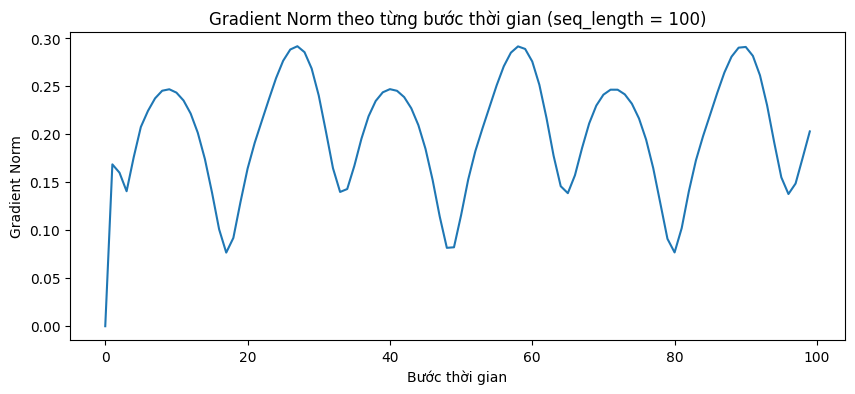

In [ ]:
# 1. Sinh dữ liệu
seq_length_long = 100
t_long = np.linspace(0, 100, 500)
data_sin = np.sin(t_long)

# Chuẩn bị dữ liệu input
X_long = torch.FloatTensor(data_sin[:seq_length_long]).unsqueeze(0).unsqueeze(-1) # (1, 100, 1)

# 2. Xây dựng RNN
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size=8):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return out # Lấy out ở tất cả các bước

model_vg = SimpleRNN(hidden_size=8)
criterion_vg = nn.MSELoss()

# Lấy output
outputs = model_vg(X_long)
target_vg = torch.zeros_like(outputs) # Target giả tạo để tính loss

grad_norms = []

# 3. Tính gradient cho từng bước thời gian
for t_step in range(seq_length_long):
    model_vg.zero_grad()
    # Loss chỉ tính tại bước t
    loss = criterion_vg(outputs[0, t_step], target_vg[0, t_step])
    loss.backward(retain_graph=True)

    # Lấy norm của gradient tương ứng của ma trận trọng số hồi quy (weight_hh_l0)
    grad_norm = model_vg.rnn.weight_hh_l0.grad.norm().item()
    grad_norms.append(grad_norm)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 4))
plt.plot(grad_norms)
plt.title(f"Gradient Norm theo từng bước thời gian (seq_length = {seq_length_long})")
plt.xlabel("Bước thời gian")
plt.ylabel("Gradient Norm")
plt.show()

In [ ]:
# 2. ANN: Flatten cửa sổ 10 chiều
class SimpleANN(nn.Module):
    def __init__(self, seq_length=10, hidden_size=20):
        super().__init__()
        self.fc1 = nn.Linear(seq_length, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape ban đầu: (batch, seq_len, 1)
        x = x.view(x.size(0), -1) # flatten thành (batch, seq_len)
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return out

model_ann = SimpleANN(seq_length=10)
# Thực hiện quá trình huấn luyện và test tương tự như RNN trong bài tập 1.